# Ressources

Youtube :

*   https://www.youtube.com/watch?v=azM57JuQpQI&list=PLZsOBAyNTZwbR08R959iCvYT3qzhxvGOE

*   https://www.youtube.com/shorts/vtcX16GF62Y

  

Articles :

*  https://towardsdatascience.com/u-net-for-semantic-segmentation-on-unbalanced-aerial-imagery-3474fa1d3e56/


Dataset :

*  https://www.kaggle.com/datasets/nublanazqalani/semantic-segmentation-makassaridn-road-dataset



# Contexte

Dans le domaine des voitures autonomes, la perception de l'environnement est une etape clé pour assurer une conduite sûre et efficace ( avant l'étape de la localisation , puis la navigation ). L'un des aspects fondamentaux de cette perception est la segmentation d'image, qui permet d'identifier et de classifier différents éléments de la route, comme les marquages surtout les lignes au sol, les autres véhicules, les piétons, les panneaux de signalisation, et bien plus encore.

En tant qu'ingénieur passionné par l'intelligence artificielle appliquée à la robotique et les systemes autonomes, je me suis intéressé à l'utilisation des réseaux de neurones convolutionnels, en particulier le modèle U-Net, pour effectuer une segmentation des routes.

Détection des lignes de voie : En identifiant correctement les peremetre de la rout pour rester toujour dans la bon voie et ça va etre fusionner avec les donnees qui viennent du LIDAR ( 3D POints Cloud >> Exemple ** Velodyne ** que justulise dans d'autre projets), pour que la véhicule autonome peut mieux suivre sa trajectoire et respecter les règles de circulation.


Dans ce projet, je me suis concentré sur la segmentation d'image avec un réseau U-Net qui peu etre integree par la suite dans un système de fusion de capteurs, afin d'améliorer la perception globale du voiture autonome.

# Objectif

L'objectif de ce projet est de développer un modèle de segmentation d'images pour les voitures autonomes, permettant d'identifier le peremetre de la route. Cette segmentation vise à améliorer la perception du véhicule et à optimiser la prise de décision en temps réel (dans l'etap localisation et navigation ). En combinant ces informations avec d'autres capteurs comme le LiDAR, IMU et le radar, nous renforçons la compréhension de l'environnement routier.

In [ ]:
from keras.layers import BatchNormalization , Activation, Conv2DTranspose , MaxPool2D , concatenate
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from keras.optimizers import Adam
from keras.models import Model
import matplotlib.pyplot as plt
from keras import backend as K
import tensorflow as tf
import numpy as np
import cv2
import os


# Data processing

Les images et les masques de segmentation sont chargés depuis leurs dossiers respectifs **JPEGImages** et **SegmentationClassPNG**, redimensionnés à une taille uniforme de 256x256 pixels (pour qu'elles etre compatible avec l'entree du modele U-net qu'on va voir just après) et normalisés pour faciliter l'apprentissage du modèle. Une dimension supplémentaire est ajoutée aux masques pour assurer la compatibilité avec le réseau de neurones.

In [ ]:


# Paths to dataset
IMAGE_PATH = "/content/drive/MyDrive/self_driving_car_data/JPEGImages"  # Path to input images
MASK_PATH = "/content/drive/MyDrive/self_driving_car_data/SegmentationClassPNG"   # Path to segmentation masks




In [ ]:
IMAGE_SIZE = (256, 256)

def load_self_driving_car_data(image_path, mask_path): # mask and image

    images = []
    masks = []

    image_files = sorted(os.listdir(image_path))
    mask_files = sorted(os.listdir(mask_path))

    for img_file, mask_file in zip(image_files, mask_files):


        img = cv2.imread(os.path.join(image_path, img_file))
        img = cv2.resize(img, IMAGE_SIZE) / 255.0  # Normalization images

        mask = cv2.imread(os.path.join(mask_path, mask_file), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, IMAGE_SIZE) / 255.0  # Normalization for masks
        mask = np.expand_dims(mask, axis=-1)  # add a channel dimension

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)



In [ ]:
X, Y = load_self_driving_car_data(IMAGE_PATH, MASK_PATH)

# Split into train set and validation set

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)



In [ ]:
print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")

Training samples: 299, Validation samples: 75


# Data augmentation

Pour améliorer la généralisation du modèle et réduire le Overfitting, des techniques d'augmentation des données sont appliquées. Ces transformations incluent des rotations, des translations, des zooms et des inversions horizontales. L'objectif est de simuler diverses conditions de conduite afin que le modèle puisse mieux s'adapter à des scénarios variés sur la route ( et voir plus de donner pour le reseau de neurone).

### Apply transformation on arrays not on the images directlly

In [ ]:

BATCH_SIZE = 8

# Create an ImageDataGenerator for augmentation
data_gen_args = dict(rotation_range=10,
                     width_shift_range=0.1,
                     height_shift_range=0.1,
                     shear_range=0.1,
                     zoom_range=0.1,
                     horizontal_flip=True,
                     fill_mode="nearest")

image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

# Define generator function
def train_generator(X_train, Y_train, batch_size):
    img_gen = image_datagen.flow(X_train, batch_size=batch_size, seed=42)
    mask_gen = mask_datagen.flow(Y_train, batch_size=batch_size, seed=42)

    while True:
        yield next(img_gen), next(mask_gen)


train_gen = train_generator(X_train, Y_train, BATCH_SIZE)


### Get 1 example from the generator

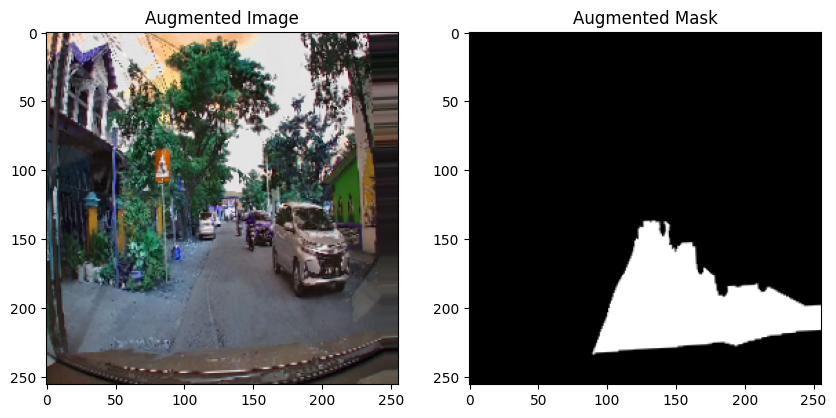

In [ ]:

# one batch
image_batch, mask_batch = next(train_gen)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_batch[0])
plt.title("Augmented Image")

plt.subplot(1, 2, 2)
plt.imshow(mask_batch[0], cmap="gray")  # Show corresponding mask
plt.title("Augmented Mask")

plt.show()


Ci-dessus nous voyons l'mage generer ainsi que le mask correspendant

In [ ]:
print(f"Shape of augmented image batch: {image_batch.shape}")  # (batch_size, height, width, channels)
print(f"Shape of augmented mask batch: {mask_batch.shape}")  # (batch_size, height, width, 1)


Shape of augmented image batch: (8, 256, 256, 3)
Shape of augmented mask batch: (8, 256, 256, 1)


8 image per batch were generated

In [ ]:
print(f"Total training samples: {len(X_train)}")
print(f"Total validation samples: {len(X_val)}")


Total training samples: 299
Total validation samples: 75


# U-net model

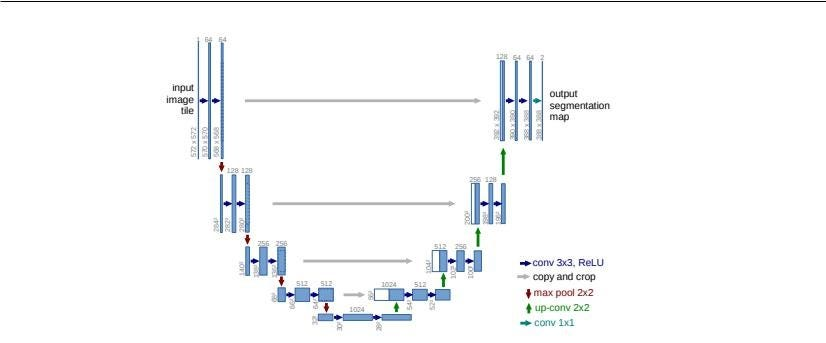

Le modèle utilisé dans ce projet est basé sur l'architecture U-Net, largement employée pour la segmentation d'images. Ce réseau est constitué de deux parties principales :

    

1.   **L'encodeur** : Il extrait progressivement les caractéristiques de l'image en appliquant des convolutions suivies de normalisations et d'activations ReLU, tout en réduisant la résolution par des opérations de pooling.
    
    
2.   **Le décodeur** : Il reconstruit l'image segmentée en remontant la hiérarchie des caractéristiques grâce à des couches de convolution transposée (Upsampling) et en fusionnant les informations de l'encodeur via des connexions de saut (skip connection) qui permet de passer quelque information du partie encoder directemnt vers le decoder.



L'entrée du modèle est une image de taille (256, 256, 3), et la sortie est une carte de segmentation binaire de la même taille, obtenue grâce à une couche finale avec activation sigmoïde. Le modèle est entraîné avec la fonction de perte Dice ( on peut utiliser d'autre mentionné dans les ressources en haut comme **Focal Loss** , **IoU Loss (Jaccard index)** , etc), qui est particulièrement adaptée pour les tâches de segmentation, car elle favorise une meilleure correspondance entre les pixels prédits et réels.

In [ ]:



class UNet():
    def __init__(self, input_shape , number_filters):

        self.input_shape = input_shape
        self.number_filters = number_filters

    def conv_block(self, input_tensor , number_filters):

            x = Conv2D(number_filters, 3 , padding='same')(input_tensor)
            x = BatchNormalization()(x) # Normalizing the input
            x = Activation("relu")(x) # Activation Function

            x = Conv2D(number_filters, 3 , padding='same')(x)
            x = BatchNormalization()(x)
            x = Activation("relu")(x)

            return x


    def encoder_block(self, input_tensor, number_filters):

         s = self.conv_block(input_tensor, number_filters)
         p = MaxPooling2D((2, 2))(s)

         return s , p

    def decoder_block(self, input_tensor, skip_feature, number_filters):

        x = Conv2DTranspose(number_filters, (2, 2), strides= 2, padding='same')(input_tensor)
        x = concatenate([x, skip_feature])
        x = self.conv_block(x, number_filters) ## 2 conv and ReLU Activation

        return x




    def build_Unet(self):

        inputs  = Input(self.input_shape)
        s1, p1 = self.encoder_block(inputs, self.number_filters)
        s2, p2 = self.encoder_block(p1, self.number_filters*2)
        s3, p3 = self.encoder_block(p2, self.number_filters*4)
        s4, p4 = self.encoder_block(p3, self.number_filters*8)

        b1 = self.conv_block(p4, self.number_filters*16) ## La base du reseau

        d1 = self.decoder_block(b1, s4, self.number_filters*8)
        d2 = self.decoder_block(d1, s3, self.number_filters*4)
        d3 = self.decoder_block(d2, s2, self.number_filters*2)
        d4 = self.decoder_block(d3, s1, self.number_filters)

        outputs = Conv2D(1, 1 , padding="same" , activation='sigmoid')(d4) # Binary Classification

        my_model = Model(inputs, outputs, name="U-Net")

        return my_model





La fonction loss utilisée

In [ ]:
import tensorflow.keras.backend as K

def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = K.batch_flatten(y_true)  # Use batch_flatten instead
    y_pred_f = K.batch_flatten(y_pred)  # Use batch_flatten instead
    intersection = K.sum(y_true_f * y_pred_f)

    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [ ]:
input_shape = (256, 256, 3)  # Image size: 256x256, RGB (3 channels)
num_filters = 64

unet_model = UNet(input_shape, num_filters)
model = unet_model.build_Unet()
model.summary()


Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 256, 256, 64)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 64)   │         36,928 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256, 256, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 256, 256, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 64)   │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 128, 128, 128)  │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 128, 128, 128)  │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 128, 128, 128)  │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 128)  │        147,584 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 128, 128, 128)  │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 128, 128, 128)  │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 64, 64, 128)    │              0 │ activation_3[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4), loss=dice_loss, metrics=["accuracy"])


# Training

In [ ]:
EPOCHS = 40
BATCH_SIZE = 8

history = model.fit(
    train_gen,  # Training generator
    validation_data=(X_val, Y_val),  # Validation data
    epochs=EPOCHS,
    steps_per_epoch=len(X_train) // BATCH_SIZE,  # Number of steps per epoch
    verbose=1
)


Epoch 1/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 196s 4s/step - accuracy: 0.6714 - loss: 0.8951 - val_accuracy: 0.0000e+00 - val_loss: 0.9419
Epoch 2/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 497ms/step - accuracy: 0.7924 - loss: 0.8159 - val_accuracy: 0.0040 - val_loss: 0.9438
Epoch 3/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 513ms/step - accuracy: 0.7990 - loss: 0.7951 - val_accuracy: 0.0067 - val_loss: 0.9438
Epoch 4/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 529ms/step - accuracy: 0.8055 - loss: 0.7865 - val_accuracy: 0.0261 - val_loss: 0.9429
Epoch 5/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 519ms/step - accuracy: 0.8141 - loss: 0.7824 - val_accuracy: 0.0239 - val_loss: 0.9430
Epoch 6/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 489ms/step - accuracy: 0.8078 - loss: 0.7750 - val_accuracy: 0.5394 - val_loss: 0.8923
Epoch 7/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 492ms/step - accuracy: 0.8037 - loss: 0.7685 - val_accuracy: 0.6358 - val_loss: 0.8711
Epoch 8/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 495ms/step - accuracy: 0.8138 - loss: 0.7682 - val_ac

L'entraînement du modèle **U-Net** a été réalisé sur 40 époques avec une taille de lot de 8. Durant les premières itérations, la fonction de perte diminue progressivement, indiquant une amélioration de l'apprentissage du modèle. L'accuracy de l'entraînement a rapidement convergé vers une valeur stable proche de 81%, tandis que l'accuracy de validation a montré une forte variation initiale avant de se stabiliser également autour de 81%. Cette tendance suggère que le modèle a bien appris à généraliser les motifs présents dans les données d'entraînement. Cependant, l'augmentation de la perte de validation vers la fin de l'entraînement peut indiquer un début de sur-apprentissage, nécessitant éventuellement une régularisation supplémentaire comme l'ajout d'une couche de dropout par exemple

# Evaluation

In [ ]:
loss, accuracy = model.evaluate(X_val, Y_val)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 399ms/step - accuracy: 0.8117 - loss: 0.7386
Validation Loss: 0.7385
Validation Accuracy: 0.8124


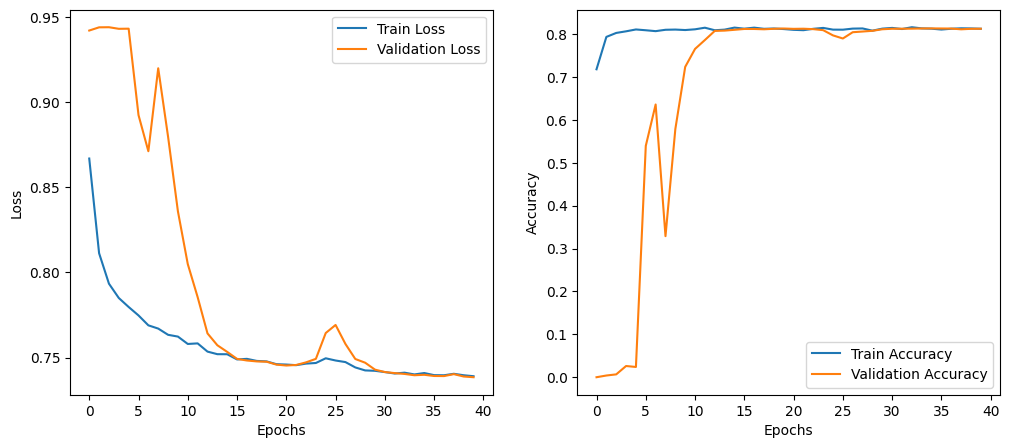

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# Test

Ici je realise une phase de test sur les images de validation afin d'évaluer la performance du modèle **U-Net** sur des données inédites. Pour ce faire, une image aléatoire a été sélectionnée et soumise au réseau pour prédiction. L'image originale et le masque de segmentation généré ont ensuite été affichés côte à côte pour une évaluation visuelle.

Le modèle a réussi à identifier la route et à générer une segmentation cohérente, avec une distinction nette entre la chaussée et les autres éléments de la scène. Toutefois, certaines imprécisions subsistent, notamment sur les contours du segment prédit. Ces résultats indiquent que le modèle a bien appris à reconnaître les motifs présents dans les images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


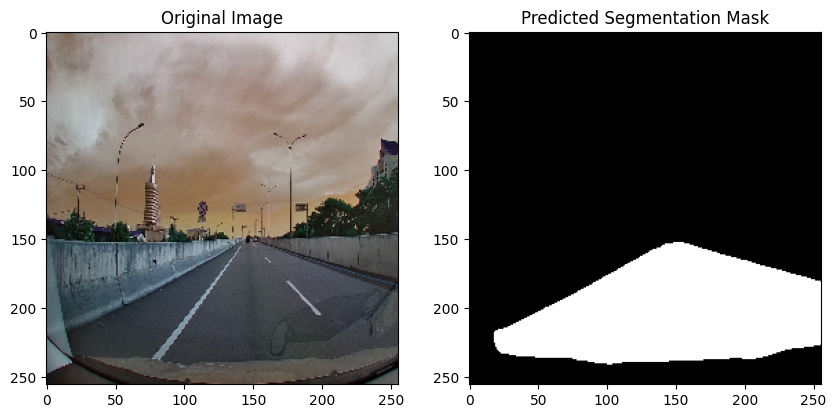

In [ ]:
import numpy as np

# I took a random image from test set
index = np.random.randint(0, len(X_val))
test_image = np.expand_dims(X_val[index], axis=0)  # add batch dimension

# Predict the mask
pred_mask = model.predict(test_image)[0]

pred_mask = (pred_mask > 0.5).astype(np.uint8)

# display original image and predicted mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(X_val[index])
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.title("Predicted Segmentation Mask")

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


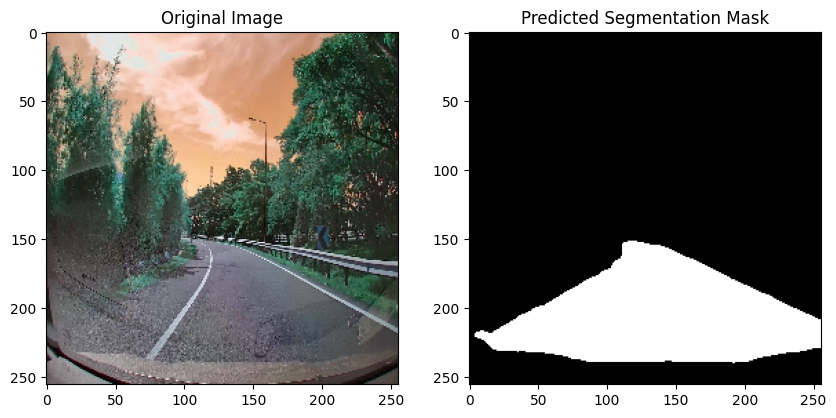

In [ ]:
import numpy as np

# I took another random image from test set
index = np.random.randint(0, len(X_val))
test_image = np.expand_dims(X_val[index], axis=0)  # add batch dimension

# Predict the mask
pred_mask = model.predict(test_image)[0]

pred_mask = (pred_mask > 0.5).astype(np.uint8)

# display original image and predicted mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(X_val[index])
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.title("Predicted Segmentation Mask")

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


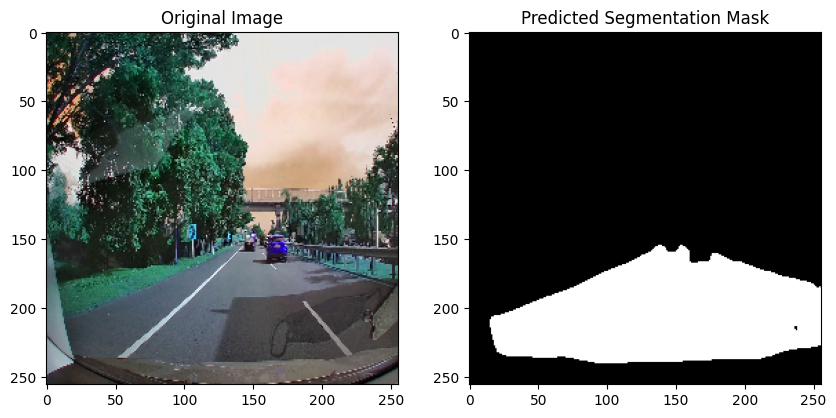

In [ ]:
import numpy as np

# I took another random image from test set
index = np.random.randint(0, len(X_val))
test_image = np.expand_dims(X_val[index], axis=0)  # add batch dimension

# Predict the mask
pred_mask = model.predict(test_image)[0]

pred_mask = (pred_mask > 0.5).astype(np.uint8)

# display original image and predicted mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(X_val[index])
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.title("Predicted Segmentation Mask")

plt.show()


# Save the trained model

In [ ]:
model.save("unet_model_saad.h5")
print("Model saved successfully!")


Model saved successfully!


# Test on video

Après l'entraînement et la validation du modèle U-Net, j'ai enregistré le modèle sous le format **.h5** afin de pouvoir l'utiliser pour tester la segmentation sur d'autre images/videos. Ce fichier contient l'architecture du modèle ainsi que les poids appris au cours de l'entraînement.

Pour évaluer la performance du modèle sur des séquences vidéo, j'ai chargé une vidéo capturée à Rabat et appliqué la segmentation image par image. Chaque frame a été redimensionnée à 256x256 pixels, normalisée, puis envoyée au modèle pour obtenir un masque de segmentation. Le masque prédit a ensuite été redimensionné à la taille originale de la vidéo et superposé à l'image d'entrée sous forme d'un filtre rouge, permettant de visualiser les zones détectées.

L'objectif de cette expérimentation est de tester l'efficacité du modèle dans des conditions réelles de conduite, en identifiant correctement le périmetre de la route cependant le modele ne peut pas detecter les autres éléments de l'environnement routier comme les ligne , les autres voitures etc. Cette approche permettrait, dans un cadre pratique, d'améliorer la perception d'un véhicule autonome et de renforcer la sécurité en combinant ces résultats avec d'autres capteurs comme le Lidar et le radar.

# Conclusion

Ce projet a permis de développer et d'évaluer un modèle de segmentation d'images basé sur **U-Net** afin d'identifier les éléments essentiels de la route à partir d'images capturées par une voiture autonome. L'entraînement et la validation du modèle ont montré des performances satisfaisantes, avec une bonne capacité à détecter les zones souhaités, illustrant l'importance de la segmentation pour la perception et la navigation des véhicules autonomes.

# Perspectifs

Comme perspectives d'évolution, il serait intéressant d'affiner le modèle en l'entraînant sur un ensemble de données plus diversifié, incluant des conditions météorologiques variées et différentes infrastructures routières. L'amélioration du modèle permettrait non seulement de détecter les lignes de signalisation au sol, mais aussi d'identifier les panneaux de signalisation, les véhicules et les autres usagers de la route. De plus, une intégration avec d'autres capteurs, tels que le **Lidar** ( **Velodyne** ) et le **radar**, pourrait renforcer la précision de la détection en utilisant la fusion de capteurs. Enfin, l'optimisation du modèle pour un déploiement en temps réel sur des systèmes embarqués serait une étape clé pour son application dans des véhicules autonomes